In [13]:
import json

# Load database
json_file = '/workspace/COMPUTERVISIONPROYECT/data/xview_detection/xview_det_train.json'
with open(json_file) as ifs:
    json_data = json.load(ifs)
ifs.close()

import pandas as pd
pd.Series([json_data[j].keys() for j in json_data],index=json_data.keys())

info                                 (description, url, version)
images         (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...
annotations    (0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...
categories                                          (0, 1, 2, 3)
dtype: object

In [5]:
import pandas as pd

imgs = pd.DataFrame(json_data['images']).T
anns = pd.DataFrame(json_data['annotations']).T

In [6]:
imgs_id_objs = imgs.set_index('image_id').num_objects.astype(int).sort_index()
anns_id_objs = anns.image_id.value_counts().sort_index()
anns_id_objs.name='num_objects'

print("Images and annotations represents the same amount of objects:\n", (imgs_id_objs == anns_id_objs).all())

Images and annotations represents the same amount of objects:
 True


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os
import pandas as pd

def visualizar_bbox(df, image_id, root_path):
    """
    Pinta una imagen y superpone las bounding boxes asociadas.
    
    Args:
        df (pd.DataFrame): El DataFrame con las anotaciones (columnas 'bbox' y 'category_id').
        image_id (str): El nombre del archivo de la imagen (ej: '418_...tif').
        root_path (str): La ruta base donde están guardadas las imágenes.
    """
    
    # 1. Cargar la imagen
    img_path = os.path.join(root_path, image_id)
    try:
        im = Image.open(img_path)
    except FileNotFoundError:
        print(f"Error: No se encontró la imagen en {img_path}")
        return

    # 2. Filtrar el DataFrame para obtener solo las filas de esta imagen
    # Verificamos si image_id es el índice o una columna para ser robustos
    if df.index.name == 'image_id':
        # Si el índice ya está seteado (como en tu primera captura)
        if image_id in df.index:
            datos_img = df.loc[[image_id]] # Usamos doble corchete para asegurar que devuelve DataFrame
        else:
            print(f"No hay anotaciones para {image_id}")
            return
    elif 'image_id' in df.columns:
        # Si image_id es una columna normal
        datos_img = df[df['image_id'] == image_id]
    else:
        # Caso de la captura donde el índice parece ser image_id pero no está explícito en el nombre
        # Asumimos que podemos acceder por loc si el df está indexado
        try:
            datos_img = df.loc[[image_id]]
        except KeyError:
            print("No se encontró el ID en el índice ni en las columnas.")
            return

    # 3. Crear la figura
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(im)
    
    # 4. Iterar sobre las anotaciones y dibujar
    for index, row in datos_img.iterrows():
        bbox = row['bbox'] # Formato esperado: [xmin, ymin, xmax, ymax]
        category = row['category_id']
        
        # Matplotlib recibe (x, y, width, height), tu data parece ser (xmin, ymin, xmax, ymax)
        xmin, ymin, xmax, ymax = bbox
        width = xmax - xmin
        height = ymax - ymin
        
        # Crear el rectángulo
        # Edgecolor 'r' (red) para que resalte sobre el mapa satelital oscuro
        rect = patches.Rectangle(
            (xmin, ymin), width, height, 
            linewidth=1.5, edgecolor='cyan', facecolor='none'
        )
        
        # Añadir el rectángulo a la imagen
        ax.add_patch(rect)
        
        # Opcional: Añadir etiqueta de texto pequeña
        ax.text(
            xmin, ymin - 2, 
            category, 
            color='white', fontsize=8, backgroundcolor='blue', alpha=0.7
        )

    plt.title(f"Visualización: {image_id}")
    plt.axis('off') # Ocultar ejes para ver mejor
    plt.show()

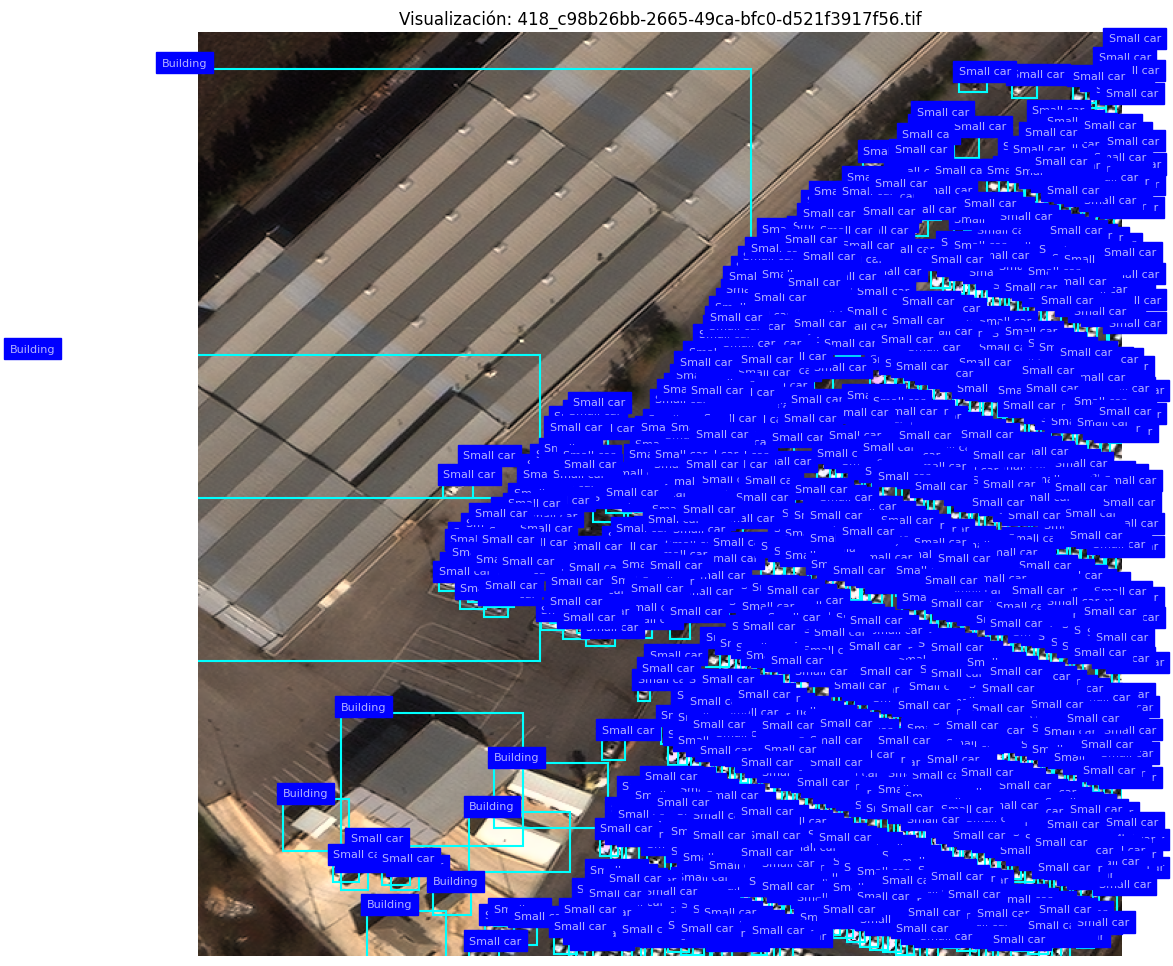

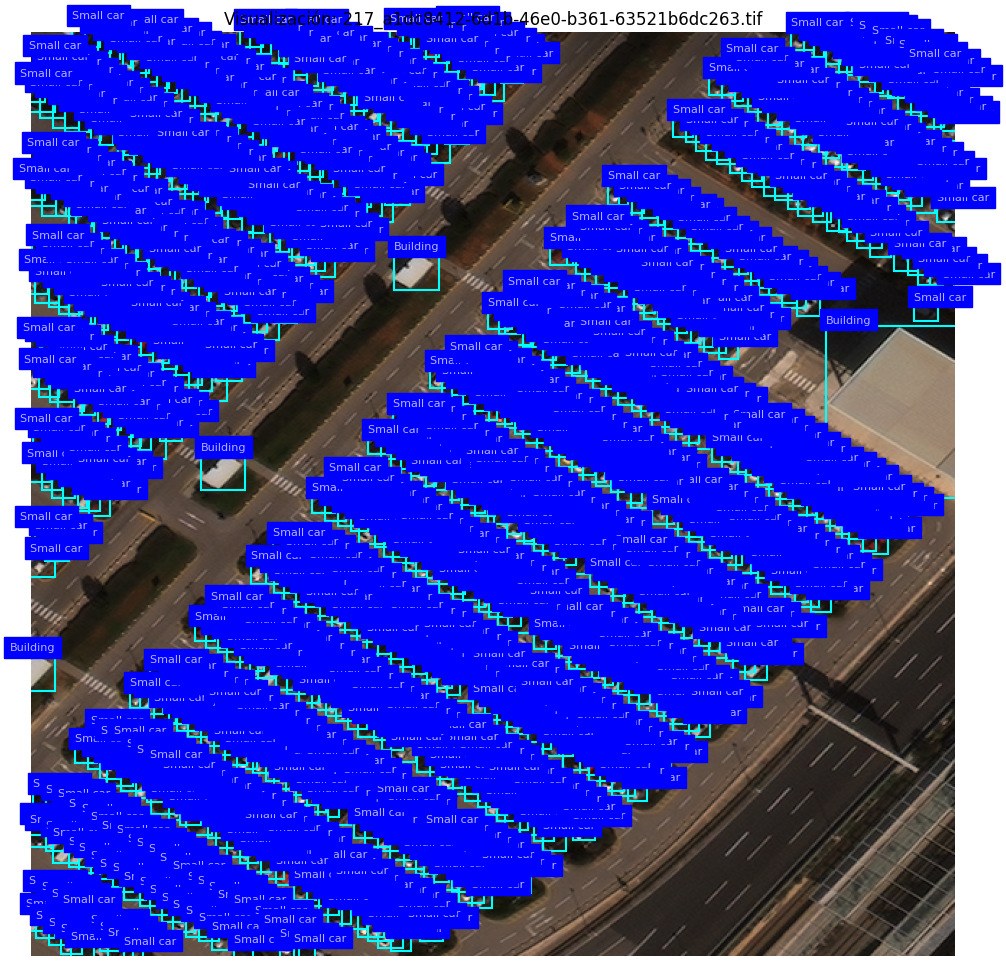

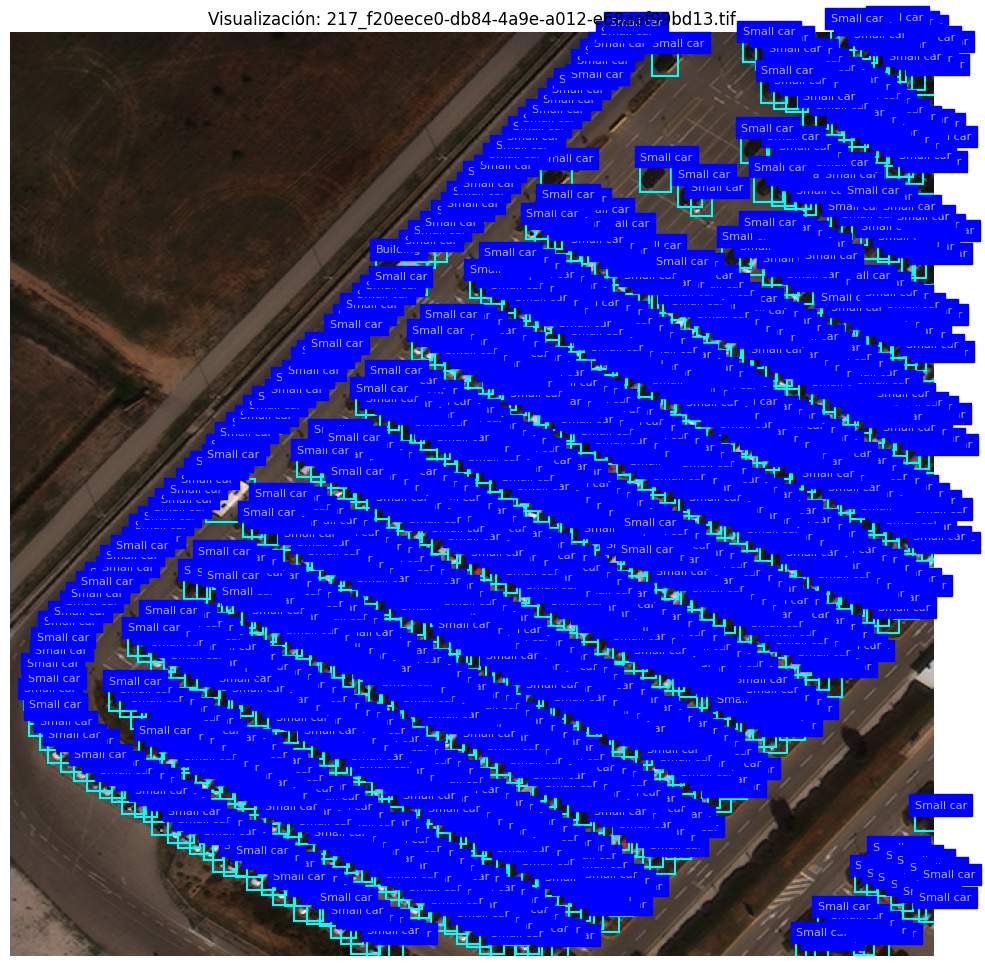

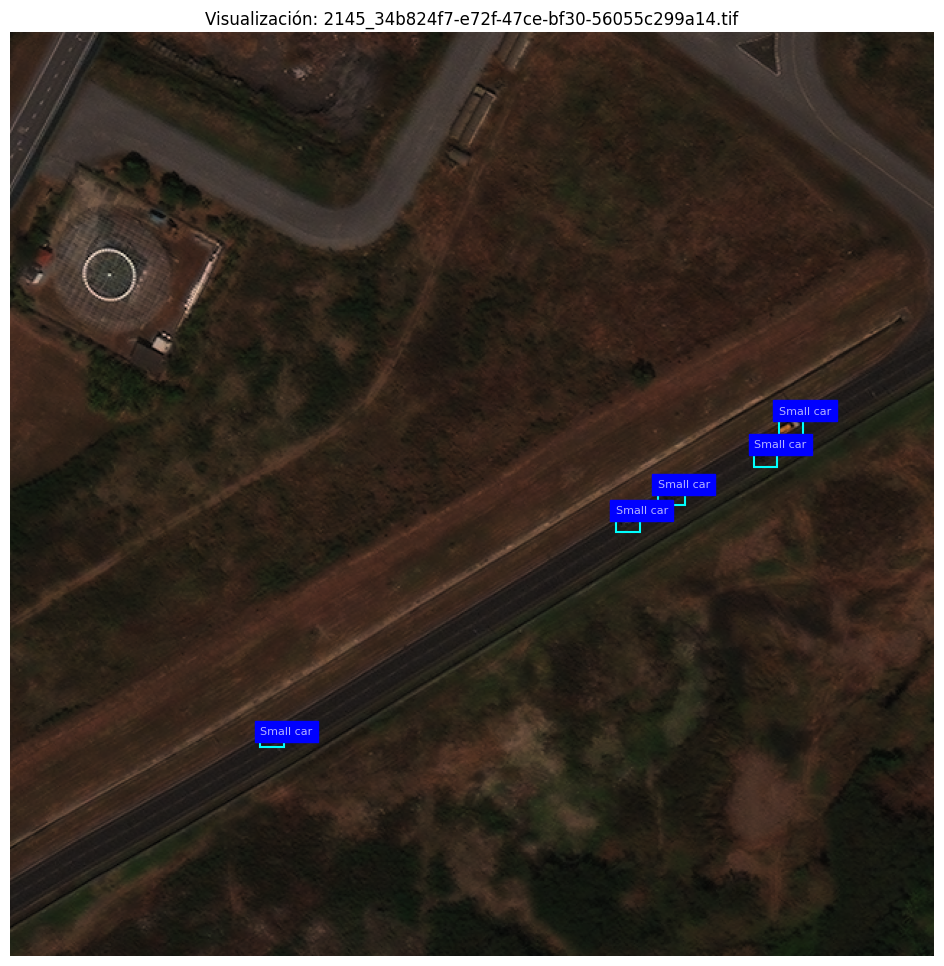

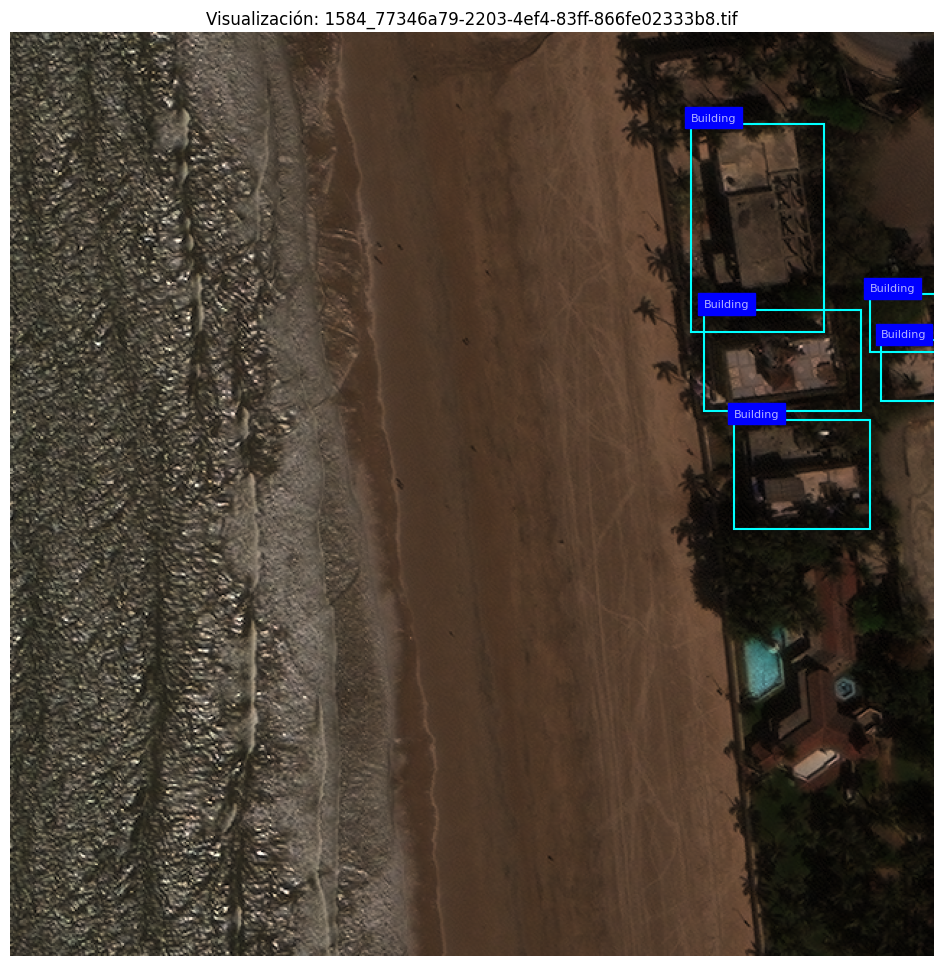

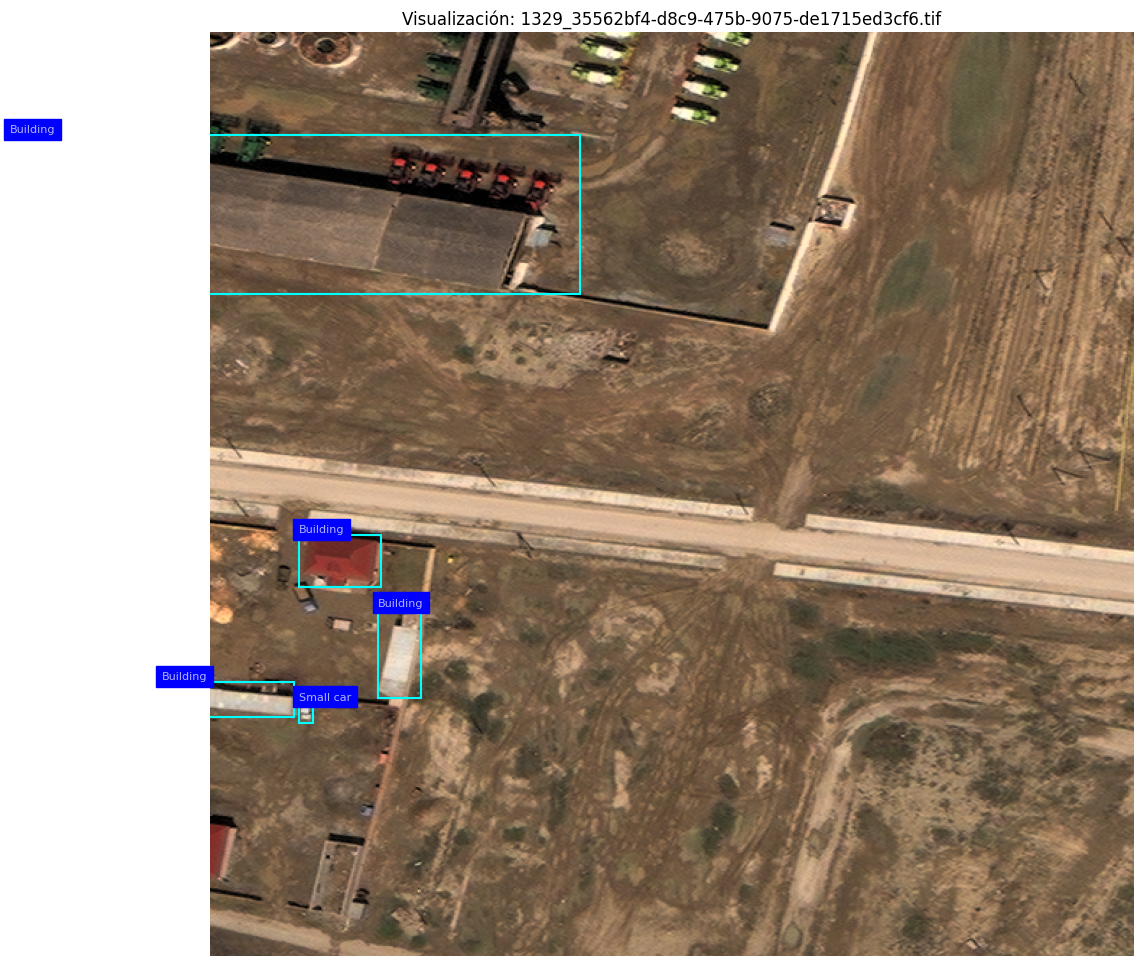

7603    None
7604    None
7605    None
dtype: object

In [40]:
root_path = '/workspace/COMPUTERVISIONPROYECT/data/xview_detection/xview_train/'
by_amnt_objs = pd.Series(anns.image_id.value_counts().index.tolist())
by_amnt_objs[:3].apply(lambda x: visualizar_bbox(anns, x, root_path))
by_amnt_objs[-3:].apply(lambda x: visualizar_bbox(anns, x, root_path))